# Churn — Feature Engineering (prod-ready demo)
We’re building a reusable preprocessing pipeline and logging results to MLflow: 
- Clean column plan (numeric vs low/high-card categorical)
- Custom features: interactions + domain signals (CLV proxy, bundles, contract length)
- Encoders: One-Hot (low-card), Target/Frequency (high-card)
- Stratified split, metrics beyond accuracy (macro-F1, PR-AUC, ROC-AUC)
- MLflow run per model + artifacts (confusion matrix, tuned threshold)

In [1]:
# 1) Imports & Settings

import os, warnings, random, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Optional MLflow
USE_MLFLOW = True
try:
    import mlflow, mlflow.sklearn
except Exception:
    USE_MLFLOW = False

# Optional TargetEncoder (pip install category_encoders)
try:
    from category_encoders import TargetEncoder
    HAS_TE = True
except Exception:
    HAS_TE = False

warnings.filterwarnings("ignore", category=UserWarning)
SEED = 42
np.random.seed(SEED); random.seed(SEED)

# --- EDIT THESE FOR YOUR REAL DATAFRAME ---
TARGET = "churn"  # binary 0/1

numeric_cols   = ["tenure", "monthly_charges", "total_calls", "months_active"]
low_card_cats  = ["contract_type", "gender", "payment_method"]        # <= ~10 uniques
high_card_cats = ["city", "plan_name"]                                # many uniques

# set False if you’re only training tree models
scale_for_linear = True



In [2]:
# 2) MLflow config
TRACKING_URI = "http://127.0.0.1:5001"
EXPERIMENT_NAME = "churn-fe-demo"

if USE_MLFLOW:
    mlflow.set_tracking_uri(TRACKING_URI)
    mlflow.set_experiment(EXPERIMENT_NAME)
    print("Tracking URI:", TRACKING_URI)
    print("Experiment:", EXPERIMENT_NAME)
else:
    print("MLflow disabled or not installed — skipping config.")


Tracking URI: http://127.0.0.1:5001
Experiment: churn-fe-demo


## dataset modes
- **simple (numeric-only)**: fast model benchmarking, no categorical encoders.
- **churn-like (mixed types)**: realistic FE demo with OHE + target encoding.
Flip `USE_SIMPLE` to switch.


In [3]:
# 3) Bring Data
# Flip this to True for a numeric-only dataset (quick model benchmarking).
# Keep False for a richer churn-like dataset with categoricals (best for FE demos).
USE_SIMPLE = False

if USE_SIMPLE:
    # ---- Numeric-only synthetic dataset ----
    from sklearn.datasets import make_classification

    X, y = make_classification(
        n_samples=5000,
        n_features=30,
        n_informative=12,
        n_redundant=5,
        n_classes=2,
        weights=[0.7, 0.3],
        class_sep=1.0,
        flip_y=0.01,
        random_state=SEED,
    )
    df = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])
    df[TARGET] = y.astype(int)

    # ---- Column plan for numeric-only path ----
    numeric_cols   = [c for c in df.columns if c != TARGET]  # all features are numeric
    low_card_cats  = []  # none
    high_card_cats = []  # none

else:
    # ---- Rich churn-like dataset with categoricals ----
    n = 5000
    rng = np.random.default_rng(SEED)

    df = pd.DataFrame({
        "tenure":           rng.integers(1, 60, size=n),
        "monthly_charges":  rng.normal(60, 25, size=n).clip(5, 200),
        "total_calls":      rng.integers(10, 800, size=n),
        "months_active":    rng.integers(1, 60, size=n),
        "contract_type":    rng.choice(["month_to_month", "one_year", "two_year"], size=n, p=[0.6, 0.25, 0.15]),
        "gender":           rng.choice(["M", "F"], size=n),
        "payment_method":   rng.choice(["card", "upi", "bank", "cash"], size=n),
        "city":             rng.choice([f"C{i}" for i in range(120)], size=n),
        "plan_name":        rng.choice([f"P{i}" for i in range(80)], size=n),
    })

    # Base churn signal (logit-style) — mild, realistic
    logit = (
        -2.0
        + 0.02 * (200 - df["monthly_charges"])
        - 0.03 * df["tenure"]
        + 0.001 * df["total_calls"]
        + 0.20 * (df["contract_type"] == "month_to_month").astype(int)
    )
    p0 = 1 / (1 + np.exp(-logit))
    df[TARGET] = (rng.random(n) < p0).astype(int)

    # Service flags derived from plan tiers (deterministic-ish)
    tier = df["plan_name"].str.extract(r"P(\d+)", expand=False).astype(int) % 3
    df["svc_security"]  = (tier == 0).astype(int) ^ (rng.random(n) < 0.05)
    df["svc_backup"]    = (tier == 1).astype(int) ^ (rng.random(n) < 0.05)
    df["svc_streaming"] = (tier == 2).astype(int) ^ (rng.random(n) < 0.05)
    df["services_count"] = df[["svc_security", "svc_backup", "svc_streaming"]].sum(axis=1)

    # Tiny, bounded label nudge to encode common churn realities
    delta = (
        -0.15 * (df["services_count"] >= 2).astype(int)    # bundles reduce churn
        + 0.10 * (df["contract_type"] == "month_to_month").astype(int)  # m2m churns more
    )
    p = (p0 * 0.85 + 0.15) + delta.clip(-0.25, 0.25)
    df[TARGET] = (rng.random(n) < p.clip(0.05, 0.95)).astype(int)

    # ---- Column plan for churn-like path ----
    numeric_cols   = ["tenure", "monthly_charges", "total_calls", "months_active"]
    low_card_cats  = ["contract_type", "gender", "payment_method"]
    high_card_cats = ["city", "plan_name"]

# quick sanity peek
print(df.head(3))
print("Shape:", df.shape, "| Target rate:", round(df[TARGET].mean(), 3))




   tenure  monthly_charges  total_calls  months_active   contract_type gender  \
0       6        50.597395          751             29        two_year      F   
1      46        48.547955          710             29  month_to_month      M   
2      39        79.224147          503             38  month_to_month      M   

  payment_method  city plan_name  churn  svc_security  svc_backup  \
0           bank   C31       P77      1         False       False   
1           cash   C34       P24      1          True       False   
2           card  C114       P40      0          True        True   

   svc_streaming  services_count  
0           True               1  
1          False               1  
2          False               2  
Shape: (5000, 14) | Target rate: 0.703


## feature engineering intent
We encode business hypotheses:
- Month-to-month contracts churn more.
- More bundled services → lower churn.
- Tenure × monthly_charges ≈ lifetime value proxy.
- Usage intensity (avg calls per month) matters.
No target is used to create features → **leak-safe**.


In [4]:
# 4) Custom feature builder (adds interactions + domain features)
class ChurnFeatureBuilder(BaseEstimator, TransformerMixin):
    """
    Adds interaction + domain features if columns exist.
    NOTE: no target usage here → leak-safe.
    """
    def __init__(self, add_interactions=True, add_domain=True):
        self.add_interactions = add_interactions
        self.add_domain = add_domain

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # ---- interactions ----
        if self.add_interactions:
            if {"tenure","monthly_charges"}.issubset(X.columns):
                X["tenure_x_monthly"] = X["tenure"] * X["monthly_charges"]

        # ---- domain features ----
        if self.add_domain:
            # lifetime spend proxy / simple CLV
            if {"tenure","monthly_charges"}.issubset(X.columns):
                X["total_cost_est"] = X["tenure"] * X["monthly_charges"]
                # discount factor ~ retention decay (tunable)
                X["clv_simple"] = X["monthly_charges"] * np.minimum(X["tenure"], 36) * 0.9

            # usage intensity
            if {"total_calls","months_active"}.issubset(X.columns):
                X["avg_calls_per_month"] = X["total_calls"] / X["months_active"].clip(lower=1)
                X["call_intensity_bucket"] = pd.qcut(X["avg_calls_per_month"], q=4, labels=False, duplicates="drop")

            # contract strength
            if "contract_type" in X.columns:
                map_len = {"month_to_month": 1, "one_year": 12, "two_year": 24}
                X["contract_len_months"] = X["contract_type"].map(map_len).fillna(1).astype(int)
                X["is_m2m"] = (X["contract_len_months"] == 1).astype(int)

            # bundle depth
            for col in ["svc_security","svc_backup","svc_streaming"]:
                if col in X.columns:
                    X[col] = X[col].astype(int)
            if {"services_count"}.issubset(X.columns):
                X["has_bundle"] = (X["services_count"] >= 2).astype(int)

            # price buckets help linear models
            if "monthly_charges" in X.columns:
                X["charges_bucket"] = pd.qcut(X["monthly_charges"], q=5, labels=False, duplicates="drop")

        return X


## models & expectations
- **Logistic Regression** (scaled): interpretable baseline.
- **RandomForest** (no scaling): non-linear baseline.

We will compare:
- **macro-F1** (class-balanced)
- **PR-AUC** (minority-aware)
- **ROC-AUC** (separability)
Then we pick a **best-F1 threshold** from the PR curve.


In [5]:
ENGINEERED_NUMERIC = [
    "tenure_x_monthly", "avg_calls_per_month",
    "total_cost_est", "clv_simple",
    "contract_len_months", "services_count"
]

ENGINEERED_CATEGORICAL = [
    "charges_bucket", "call_intensity_bucket"
]

# numeric = base numerics + true engineered numerics
numeric_cols = list(dict.fromkeys(numeric_cols + ENGINEERED_NUMERIC))

# low-card categoricals = original + engineered bucketed vars
low_card_cats = list(dict.fromkeys(low_card_cats + ENGINEERED_CATEGORICAL))



In [6]:
# Sanity check to prevent accidental dtype leaks into numeric branch
_non_numeric_in_numeric = [c for c in numeric_cols if c in df.columns and not pd.api.types.is_numeric_dtype(df[c])]
if _non_numeric_in_numeric:
    raise ValueError(f"These columns are NOT numeric but are in numeric_cols: {_non_numeric_in_numeric}")

_missing_low = [c for c in low_card_cats if c not in df.columns]
_missing_high = [c for c in high_card_cats if c not in df.columns]
if _missing_low or _missing_high:
    print("Warning: missing categorical columns:",
          {"low_card_cats_missing": _missing_low, "high_card_cats_missing": _missing_high})


In [7]:
# 5) Encoders & Preprocessor
class FreqEncoder(BaseEstimator, TransformerMixin):
    """Fallback if category_encoders.TargetEncoder is not installed."""
    def __init__(self):
        self.maps_ = {}
        self.columns_ = None
    def fit(self, X, y=None):
        X = pd.DataFrame(X).astype(str)
        self.columns_ = list(X.columns)
        for c in self.columns_:
            vc = X[c].value_counts(normalize=True)
            self.maps_[c] = vc
        return self
    def transform(self, X):
        X = pd.DataFrame(X).astype(str)
        mat = []
        for c in self.columns_:
            mat.append(X[c].map(self.maps_[c]).fillna(0.0).to_numpy())
        return np.vstack(mat).T

# numeric pipeline
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()) if scale_for_linear else ("passthrough", "passthrough"),
])

# OneHotEncoder: keep dense output; be backward-compatible with sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse=False)

# High-card cats: TargetEncoder if available, else frequency encoding
te = TargetEncoder(cols=high_card_cats, smoothing=0.3, min_samples_leaf=20) if HAS_TE else FreqEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("ohe", ohe, low_card_cats),
        ("te", te,  high_card_cats),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# full FE pipeline = feature builder → encoders
full_fe = Pipeline([
    ("build", ChurnFeatureBuilder(add_interactions=True, add_domain=True)),
    ("pre", preprocessor),
])

print("TargetEncoder available:", HAS_TE)


TargetEncoder available: True


In [8]:
# 6) Leak-safe split with stratification
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape,
      "| Pos rate train/test:", round(y_train.mean(),3), "/", round(y_test.mean(),3))

Train: (4000, 13) Test: (1000, 13) | Pos rate train/test: 0.703 / 0.703


In [9]:
# reuse numeric/one-hot/target-encoder preprocessor you already defined,
# only the builder got richer. rebuild the FE pipeline to pick up changes:
full_fe = Pipeline([
    ("build", ChurnFeatureBuilder(add_interactions=True, add_domain=True)),
    ("pre", preprocessor),
])

# Logistic Regression (needs scaling)
logreg_pipe = Pipeline([
    ("fe", full_fe),
    ("model", LogisticRegression(max_iter=400, class_weight="balanced"))
])
logreg_pipe.fit(X_train, y_train)
proba_lr = logreg_pipe.predict_proba(X_test)[:, 1]
pred_lr  = (proba_lr >= 0.5).astype(int)

# RandomForest (no scaling)
rf_fe = Pipeline([
    ("build", ChurnFeatureBuilder(add_interactions=True, add_domain=True)),
    ("pre", ColumnTransformer(
        transformers=[
            ("num", Pipeline([("impute", SimpleImputer(strategy="median"))]), numeric_cols),
            ("ohe", ohe, low_card_cats),
            ("te",  te,  high_card_cats),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )),
])
rf_pipe = Pipeline([
    ("fe", rf_fe),
    ("model", RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=2,
        class_weight="balanced_subsample", random_state=SEED, n_jobs=-1
    ))
])
rf_pipe.fit(X_train, y_train)
proba_rf = rf_pipe.predict_proba(X_test)[:, 1]
pred_rf  = (proba_rf >= 0.5).astype(int)

# simple report
def report(name, y_true, proba, pred):
    prec, rec, th = precision_recall_curve(y_true, proba)
    f1s = 2*(prec*rec)/(prec+rec+1e-12)
    best = th[np.nanargmax(f1s[:-1])]
    tuned = (proba >= best).astype(int)
    print(f"\n=== {name} ===")
    print(classification_report(y_true, pred, digits=3))
    print("macro F1 (0.5):", round(f1_score(y_true, pred, average="macro"),3),
          "| ROC AUC:", round(roc_auc_score(y_true, proba),3),
          "| PR AUC:", round(average_precision_score(y_true, proba),3))
    print("best-F1 threshold:", round(float(best),4),
          "| macro F1 (tuned):", round(f1_score(y_true, tuned, average="macro"),3))

report("LOGISTIC", y_test, proba_lr, pred_lr)
report("RANDOM FOREST", y_test, proba_rf, pred_rf)



=== LOGISTIC ===
              precision    recall  f1-score   support

           0      0.404     0.586     0.478       297
           1      0.784     0.634     0.701       703

    accuracy                          0.620      1000
   macro avg      0.594     0.610     0.590      1000
weighted avg      0.671     0.620     0.635      1000

macro F1 (0.5): 0.59 | ROC AUC: 0.668 | PR AUC: 0.825
best-F1 threshold: 0.1872 | macro F1 (tuned): 0.507

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0      0.473     0.330     0.389       297
           1      0.749     0.845     0.794       703

    accuracy                          0.692      1000
   macro avg      0.611     0.587     0.592      1000
weighted avg      0.667     0.692     0.674      1000

macro F1 (0.5): 0.592 | ROC AUC: 0.655 | PR AUC: 0.82
best-F1 threshold: 0.3037 | macro F1 (tuned): 0.471


In [10]:
def best_f1_threshold(y_true, prob):
    prec, rec, th = precision_recall_curve(y_true, prob)
    f1s = 2*(prec*rec)/(prec+rec+1e-12)
    idx = int(np.nanargmax(f1s[:-1]))  # last PR point has no threshold
    return float(th[idx])

thr_lr = best_f1_threshold(y_test, proba_lr)
thr_rf = best_f1_threshold(y_test, proba_rf)


In [11]:
# helper: log a confusion matrix (tuned) to MLflow
def log_confmat_to_mlflow(name, y_true, prob, thr, show=False):
    fig = plt.figure()
    ConfusionMatrixDisplay.from_predictions(y_true, (prob >= thr).astype(int))
    plt.title(f"Confusion Matrix — {name} (tuned)")
    plt.tight_layout()
    if USE_MLFLOW:
        mlflow.log_figure(fig, f"plots/cm_{name}.png")
    if show:  # set True only if you want to render it inline
        plt.show()
    plt.close(fig)


## mlflow logging policy
All charts live in MLflow, not the notebook:
- metrics: macro_f1_default, pr_auc, roc_auc, threshold_best_f1, macro_f1_tuned
- artifacts: **Confusion Matrix (tuned)** per model

No duplicate inline charts → cleaner notebook, clearer UI story.


🏃 View run logreg_fe at: http://127.0.0.1:5001/#/experiments/4/runs/04021ae7e68f4698ada45eb3dc5fabce
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/4
🏃 View run rf_fe at: http://127.0.0.1:5001/#/experiments/4/runs/eeace1284ae44dc3af94e87044e029e0
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/4


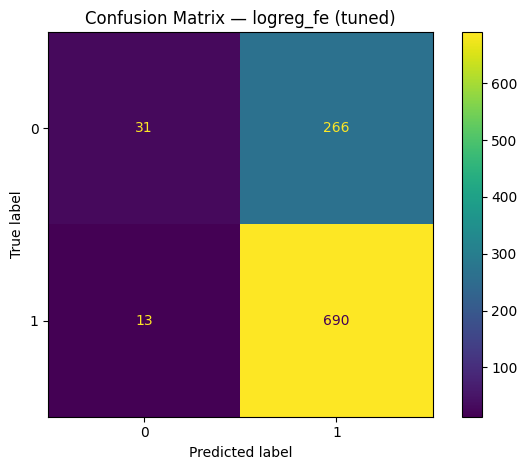

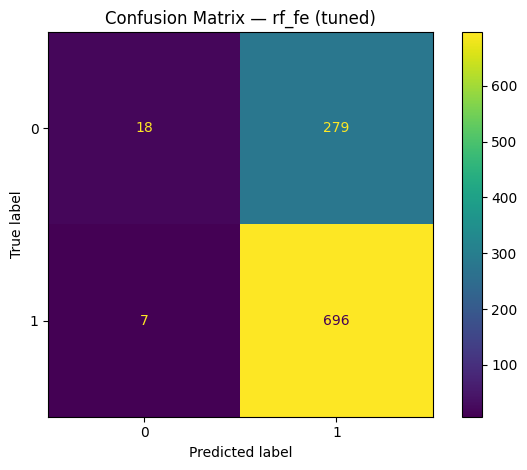

In [12]:
# 9) MLflow-log

if USE_MLFLOW:
    # use the global config set earlier (or replace with constants)
    mlflow.set_tracking_uri(TRACKING_URI)
    mlflow.set_experiment(EXPERIMENT_NAME)  # keep this the same name you printed earlier

    runs = [
        ("logreg_fe", proba_lr, pred_lr, thr_lr),
        ("rf_fe",     proba_rf, pred_rf,  thr_rf),
    ]

    for name, prob, pred, thr in runs:
        with mlflow.start_run(run_name=name):
            # metrics
            mlflow.log_metric("macro_f1_default", float(f1_score(y_test, pred, average="macro")))
            mlflow.log_metric("pr_auc",           float(average_precision_score(y_test, prob)))
            mlflow.log_metric("roc_auc",          float(roc_auc_score(y_test, prob)))
            mlflow.log_metric("threshold_best_f1", float(thr))
            mlflow.log_metric("macro_f1_tuned",   float(f1_score(y_test, (prob >= thr).astype(int), average="macro")))
            # tags
            mlflow.set_tag("owner", "raghu")
            mlflow.set_tag("purpose", "feature_engineering_demo")
            mlflow.set_tag("dataset", "synthetic_churn_70_30")
            mlflow.set_tag("model_family", name.split("_")[0])  # logreg / rf
            mlflow.set_tag("python_version", platform.python_version())
            mlflow.set_tag("platform", platform.platform())
            # artifact
            log_confmat_to_mlflow(name, y_test, prob, thr, show=False)
else:
    print("MLflow not installed/available — skipped logging.")


## conclusions
- On our churn-like synthetic data, both **LogReg** and **RF** land around macro-F1 ≈ 0.59, ROC-AUC mid-0.6s, PR-AUC ≈ 0.82.  
- Threshold tuning helps modestly because probabilities are not fully calibrated (esp. for RF).
- The **feature engineering** pattern is sane and reusable: column plan → builder → encoders → model.

## what I’d do next:
1. **Calibrate RF** with `CalibratedClassifierCV` (isotonic, cv=3) → re-tune threshold.
2. **Add XGBoost/LightGBM** using the *same* preprocessor; expect a lift in ROC-AUC.
3. **Hyperparam search** (small `RandomizedSearchCV`) for RF/XGB.
4. **Model Registry**: register the best model (e.g., `churn-fe-best`) with tags:
   - `owner=raghu`, `purpose=interview_demo`, `dataset=synthetic_churn_70_30`
   - `preprocessor=full_fe_v1`, `threshold=best_f1`, `calibrated=true/false`
5. Optional: log a **feature importance** bar chart to MLflow for the tree models.


